# Short recurrent rhythms: particles 1, 3, 5 and 7

**Question:** does a short pattern recur regularly, and does its timing remain stable over the saved 5,000 forcing cycles? The analysis identifies recurrent rhythms at a few cycles, measures many successive revolutions, and tests the persistence of a fixed integer-cycle pattern.

The source is the saved **BM4Implicit** integration with **40 steps per cycle**. This notebook reads the checksum-verified once-per-cycle CSV and verified original initial states. Run all cells in the project Python environment; no trajectory integration is performed. The original particle IDs and physics remain explicit below.

Only one position per forcing cycle is available locally. The geometric clock below measures rotation of the sampled Poincare section; its fractional crossing times are interpolated. It does not resolve the within-cycle physical path. No independently audited trajectory reference covers this complete run.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from diagnostics.paths import find_project_root
from diagnostics.poincare_periodicity import export_short_periodicity
from studies.poincare_periodicity import (
    load_saved_poincare_section, analyze_short_periodicity,
    short_periodicity_interpretation,
)
from visualization.poincare_periodicity import (
    plot_section_initial_positions, plot_short_periodicity,
    plot_residue_section, show_periodicity_figure,
)

PROJECT = find_project_root(Path.cwd())
STUDY = PROJECT / 'notebooks/developements/poincare_section/Poincare_BM4Implicit_24_impares_5000_ciclos_40_steps_spot'
RUN_ID = 'aws_bm4implicit_24odd_5000c_40s_20260920'
PARTICLE_IDS = (1, 3, 5, 7)

# Immutable source-run physics and numerics; changing these requires matching saved data.
CYCLES = 5000
STEPS_PER_CYCLE = 40
CYCLE_DURATION = 1.0
T0 = 0.0
RHO = 0.3
COUPLING_FREQUENCY = np.pi / 8
RADIAL_FRACTIONS = (0.0, 0.020851063829787235, 0.04170212765957447, 0.0625531914893617)
RADIAL_ANGLE_RAD = 0.0
B_TESLA = 1.5
CHARACTERISTIC_LENGTH_M = 0.06
SOURCE_SELECTION = (0, 1)
INTERPOLATION_ORDER = 3
FIELD_SHA256 = '4bbd873cd05992e0a615d66ebbf4d96b38c8b3c36be2ca62932e66af7e6d4ced'
NEWTON_ATOL = 1e-12
NEWTON_RTOL = 1e-11
NEWTON_MAX_CORRECTIONS = 40
JACOBIAN_RELATIVE_STEP = np.cbrt(np.finfo(float).eps)

# Editable analysis controls; no random sampling or seed is used.
# Identify the first recurrent peak at a short lag; retain later peaks as confirmation.
MAX_LAG = 80
CANDIDATE_MAX_LAG = 20
PEAK_HEIGHT = 0.5
PEAK_PROMINENCE = 0.2
MULTIPLE_COUNT = 20
BLOCK_CYCLES = 500
PREVIEW_CYCLES = 80
THRESHOLDS_OVER_L = (1e-3, 5e-3, 1e-2, 2e-2)
RESONANCE_PARTICLE = 5
RESONANCE_LAG = 8
RESONANCE_RESIDUE = 0
SAVE_PRODUCTS = True
FIGURES = STUDY / 'figuras' / RUN_ID / 'short_periodicity_particles_1_3_5_7'
DIAGNOSTICS = STUDY / 'resultados' / RUN_ID / 'short_periodicity_particles_1_3_5_7'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

Verified source: aws_bm4implicit_24odd_5000c_40s_20260920; L=18.8495559215; integration step=0.025
Forcing cycle: 0.00261352184253 s; coordinate unit: 0.00954929658551 m
Potential: PHI_2.h5; SHA256: 4bbd873cd05992e0a615d66ebbf4d96b38c8b3c36be2ca62932e66af7e6d4ced
Selected initial states (coordinates and spatial radii divided by L):


,particle,x_over_L,y_over_L,radius_over_L,color
0,1,0.500000,0.5,0.000000,#372466
1,3,0.520851,0.5,0.020851,#4040a2
2,5,0.541702,0.5,0.041702,#455ed3
3,7,0.562553,0.5,0.062553,#4778f0


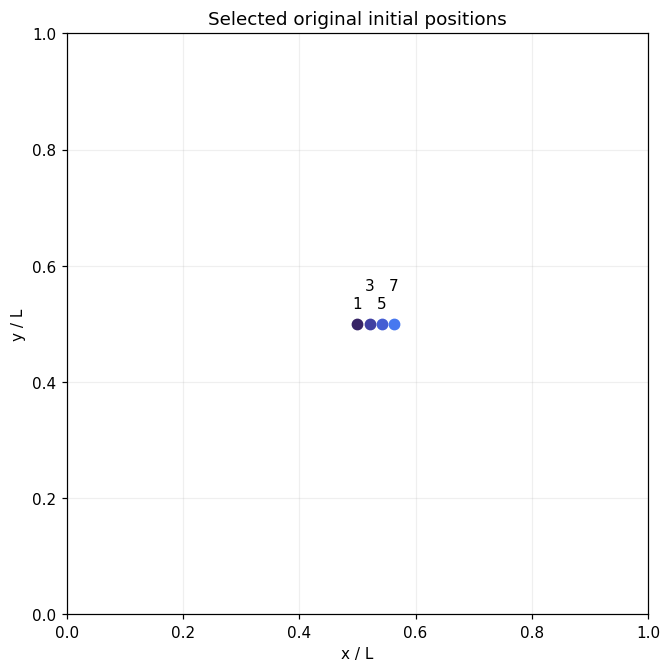

In [2]:
section = load_saved_poincare_section(STUDY, RUN_ID, PARTICLE_IDS)
meta = section.metadata
field = meta['field_provenance']
L = field['grid']['period']
assert meta['method'] == 'BM4Implicit' and meta['arithmetic'] == 'float64'
assert section.positions.shape == (CYCLES + 1, len(PARTICLE_IDS), 2)
assert meta['cycles'] == CYCLES and meta['steps_per_cycle'] == STEPS_PER_CYCLE
assert meta['complete_steps'] == CYCLES * STEPS_PER_CYCLE
assert meta['newton_max_iterations'] == NEWTON_MAX_CORRECTIONS
assert meta['newton_jacobian'] == 'analytic' and meta['nonlinear_solver'] == 'newton'
assert tuple(field['source_selection']) == SOURCE_SELECTION
assert field['interpolation_order'] == INTERPOLATION_ORDER
assert field['source_hdf5_sha256'] == FIELD_SHA256
np.testing.assert_allclose(
    [meta['rho'], meta['coupling_frequency'], meta['radial_angle_rad'], meta['t0'],
     meta['cycle_duration'], meta['step'], meta['newton_atol'], meta['newton_rtol'],
     meta['jacobian_relative_step'], field['B_tesla'], field['characteristic_length_m']],
    [RHO, COUPLING_FREQUENCY, RADIAL_ANGLE_RAD, T0, CYCLE_DURATION,
     CYCLE_DURATION / STEPS_PER_CYCLE, NEWTON_ATOL, NEWTON_RTOL,
     JACOBIAN_RELATIVE_STEP, B_TESLA, CHARACTERISTIC_LENGTH_M], rtol=1e-14, atol=0,
)
np.testing.assert_allclose(meta['t_span'], [T0, T0 + CYCLES * CYCLE_DURATION])
np.testing.assert_allclose([r['radius_over_L'] for r in section.initial_records], RADIAL_FRACTIONS)
print(f"Verified source: {RUN_ID}; L={L:.12g}; integration step={meta['step']:g}")
print(f"Forcing cycle: {meta['time_scale_s']:.12g} s; coordinate unit: {meta['length_scale_m']:.12g} m")
print('Potential: PHI_2.h5; SHA256:', FIELD_SHA256)
print('Selected initial states (coordinates and spatial radii divided by L):')
display(pd.DataFrame(section.initial_records))
show_periodicity_figure(plot_section_initial_positions(section),
                        FIGURES if SAVE_PRODUCTS else None, 'initial_positions')

## How a short recurring pattern is detected

1. **Short-lag autocorrelation.** Form the four smooth observables $u_n=(\sin(2\pi x_n/L),\sin(2\pi y_n/L),\cos(2\pi x_n/L),\cos(2\pi y_n/L))$ and subtract their record means. At lag $q$, compute the normalized inner product of $u_{n+q}$ and $u_n$ over every overlapping pair. A rhythm produces a sequence of positive peaks. The candidate is the **first** local peak within 20 cycles with height at least 0.5 and prominence at least 0.2. Retain peaks through 80 cycles to inspect recurring spacing. No distant minimum selects the candidate.
2. **Revolution timing.** Center the section using its circular spatial centroid, form minimum-image displacements and unwrap their polar angle. Only a localized section with strictly monotone resolved angular motion is accepted. Interpolate successive complete turns and report their mean duration and means in disjoint 500-cycle blocks. This clock assumes angular motion is resolved by the saved samples; fractional times and the spread of individual durations include interpolation effects.
3. **Persistence at a fixed integer period.** Compare $z_{n+kq}$ with $z_n$ for $k=1,\ldots,20$, using every valid starting cycle and the minimum-image spatial distance divided by $L$. A noninteger rhythm accumulates phase drift relative to $q$. A persistent $q$-cycle island pattern can retain small, modulated defects at its multiples.
4. **Held-out fixed pattern.** Average the four observables separately for each residue $n\bmod q$ in the first half, then predict the second half. Report $S=1-\mathrm{SSE}_{q}/\mathrm{SSE}_{constant}$, where the constant baseline is the first-half mean. A score near 1 indicates persistence of the same $q$-cycle pattern; 0 means no gain over the constant baseline and a negative score means poorer prediction. A stable noninteger rhythm can score near zero. This tests the selected candidate; it is not independent statistical discovery of its period.

In [3]:
analysis = analyze_short_periodicity(
    section.positions, PARTICLE_IDS, max_lag=MAX_LAG,
    candidate_max_lag=CANDIDATE_MAX_LAG, peak_height=PEAK_HEIGHT,
    peak_prominence=PEAK_PROMINENCE, multiple_count=MULTIPLE_COUNT,
    block_cycles=BLOCK_CYCLES, threshold_fractions=THRESHOLDS_OVER_L,
)
summary = pd.DataFrame(analysis.summary).set_index('particle')
display(summary[['short_q', 'correlation', 'mean_rotation_cycles',
                 'block_period_min', 'block_period_max', 'measured_revolutions',
                 'heldout_template_score']])
print('The integer short_q and the geometric mean revolution duration are distinct diagnostics.')

,short_q,correlation,mean_rotation_cycles,block_period_min,block_period_max,measured_revolutions,heldout_template_score
particle,,,,,,,
1,8,0.990953,7.842393,7.841030,7.843967,636,-0.002173
3,7,0.995187,6.901003,6.899566,6.901593,723,0.000225
5,8,0.998277,8.000025,7.997396,7.999722,623,0.997970
7,9,0.989417,8.868858,8.775206,9.063337,562,-0.022257


The integer short_q and the geometric mean revolution duration are distinct diagnostics.


## Recurrence every few cycles

The first figure shows the first 80 cycles without temporal subsampling. The autocorrelation uses the complete 5,000-cycle record. Look for a repeating sequence of peaks, allowing alternating integer spacings when the mean rhythm is noninteger. Correlation is normalized independently for each particle.

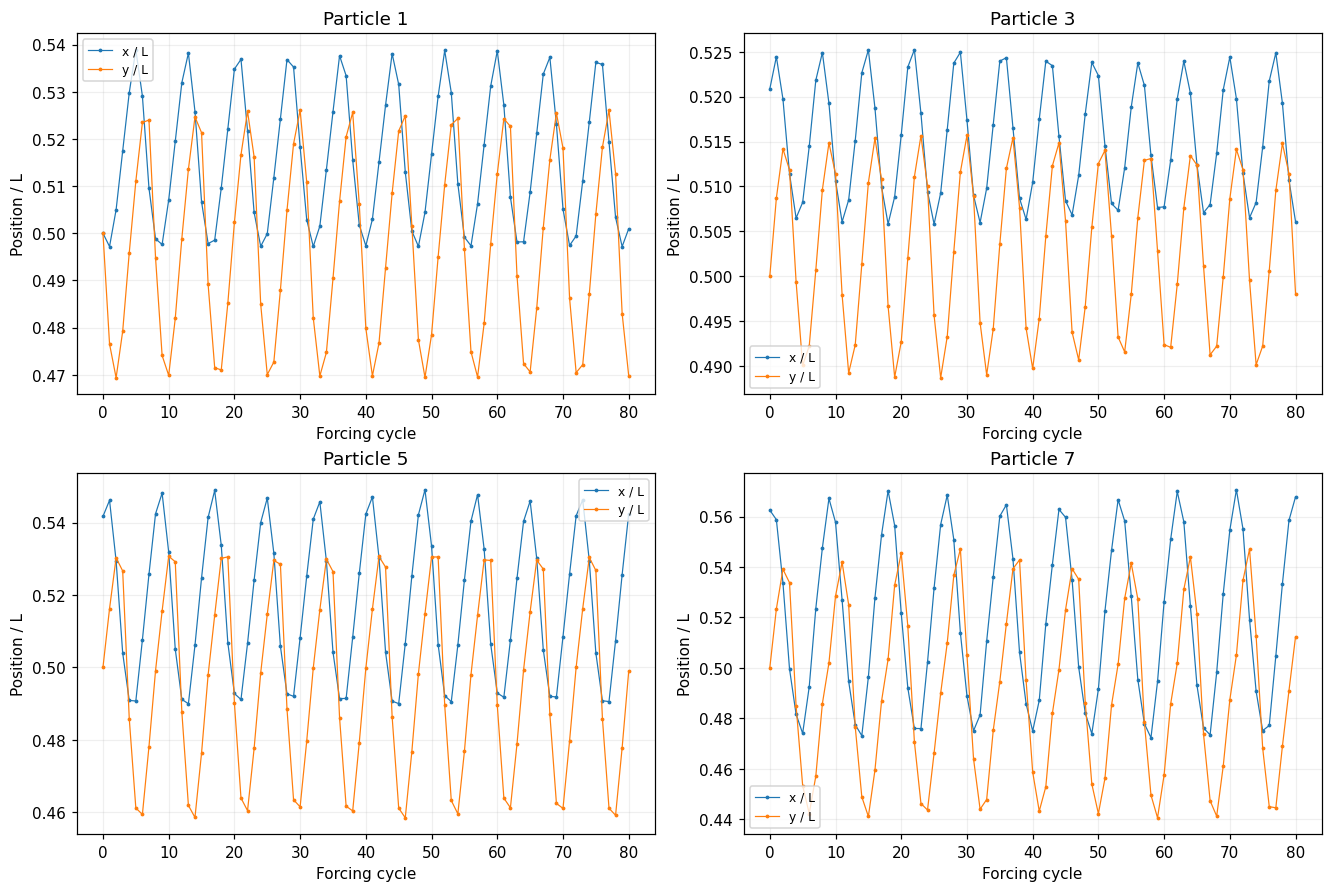

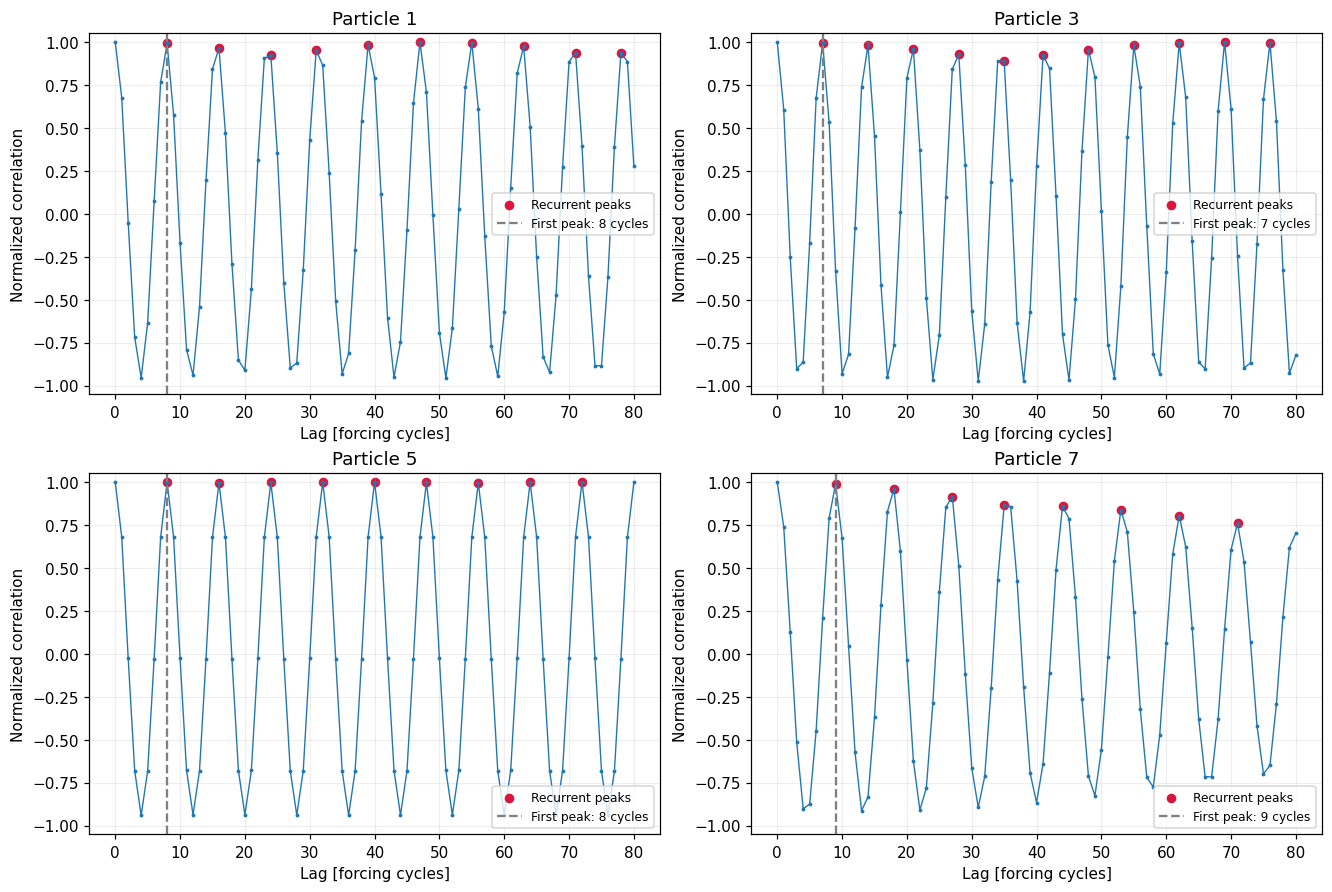

,recurring_peak_lags,successive_intervals
particle,,
1,"[8, 16, 24, 31, 39, 47, 55, 63, 71, 78]","[8, 8, 7, 8, 8, 8, 8, 8, 7]"
3,"[7, 14, 21, 28, 35, 41, 48, 55, 62, 69, 76]","[7, 7, 7, 7, 6, 7, 7, 7, 7, 7]"
5,"[8, 16, 24, 32, 40, 48, 56, 64, 72]","[8, 8, 8, 8, 8, 8, 8, 8]"
7,"[9, 18, 27, 35, 44, 53, 62, 71]","[9, 9, 8, 9, 9, 9, 9]"


In [4]:
for diagnostic in ('signals', 'correlations'):
    show_periodicity_figure(
        plot_short_periodicity(section, analysis, diagnostic=diagnostic, preview_cycles=PREVIEW_CYCLES),
        FIGURES if SAVE_PRODUCTS else None, diagnostic,
    )
peaks = pd.DataFrame(analysis.peaks)
display(peaks.groupby('particle').agg(
    recurring_peak_lags=('lag', list),
    successive_intervals=('interval_from_previous', lambda s: s.dropna().astype(int).tolist()),
))

## Does the rhythm persist through time?

Each dot is the interpolated duration between two consecutive full geometric turns. Red segments are averages within disjoint 500-cycle windows. The integer candidate is shown as a dotted line. Variation within a window can include sampling/interpolation effects and modulation; a systematic shift in window means is stronger evidence of a changing numerical rhythm.

The accompanying table reports the autocorrelation and spatial repetition defect at the same short candidate separately in every time block. No pair crosses a block boundary.

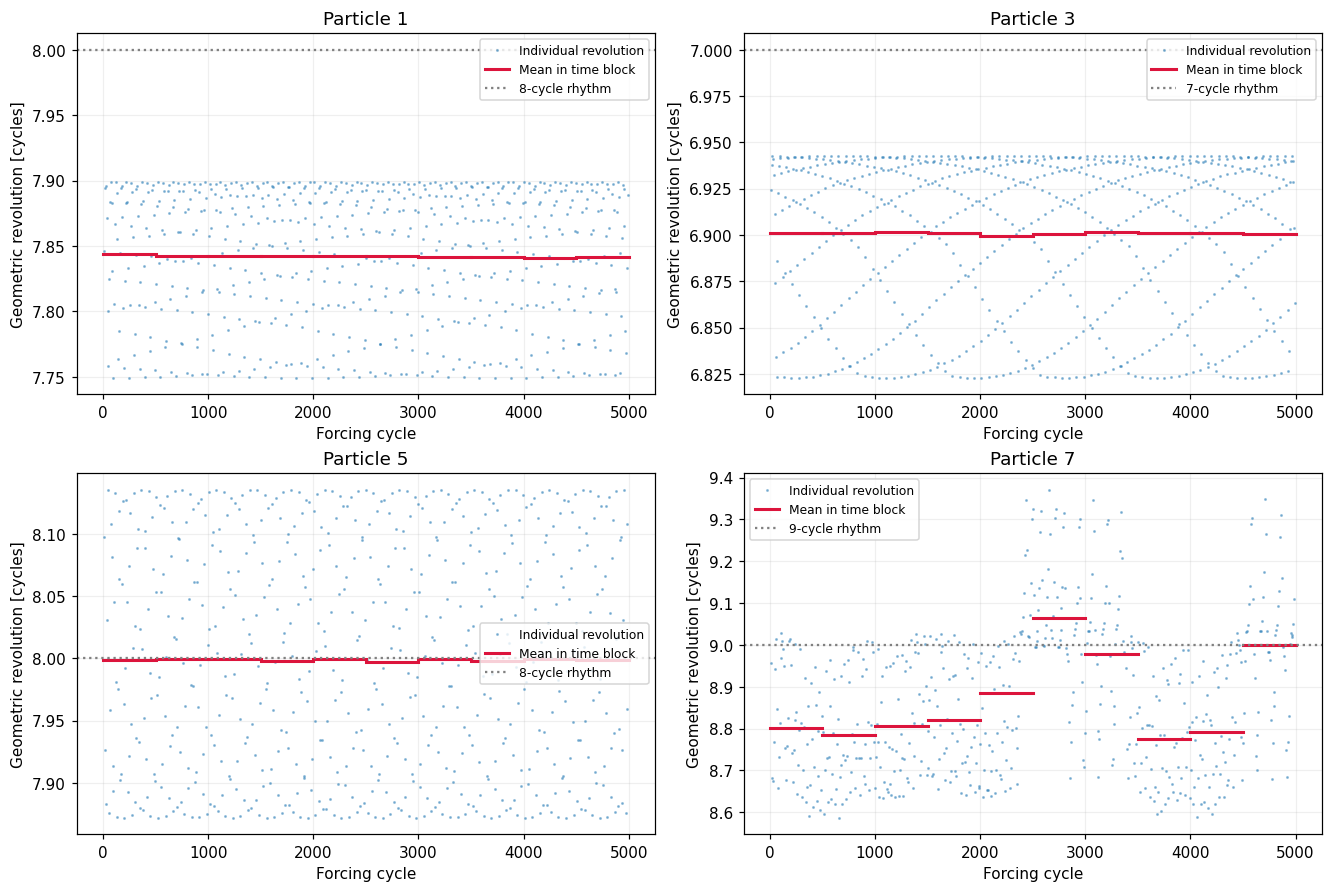

,particle,start_cycle,stop_cycle_exclusive,q,correlation,rms_over_L,max_over_L,mean_rotation_cycles
0,1,0,500,8,0.990923,0.003288,0.005780,7.843967
1,1,500,1000,8,0.990957,0.003286,0.005802,7.842707
2,1,1000,1500,8,0.990962,0.003285,0.005807,7.842573
3,1,1500,2000,8,0.991004,0.003276,0.005796,7.842266
4,1,2000,2500,8,0.990997,0.003275,0.005777,7.842049
5,1,2500,3000,8,0.991012,0.003275,0.005806,7.842216
6,1,3000,3500,8,0.991010,0.003276,0.005807,7.842010
7,1,3500,4000,8,0.990996,0.003276,0.005796,7.841937
8,1,4000,4500,8,0.991016,0.003272,0.005787,7.841030
9,1,4500,5000,8,0.990970,0.003282,0.005807,7.841956


In [5]:
show_periodicity_figure(plot_short_periodicity(section, analysis, diagnostic='blocks'),
                        FIGURES if SAVE_PRODUCTS else None, 'rhythm_stability')
display(pd.DataFrame(analysis.blocks))

## A recurring rhythm versus a fixed integer-cycle pattern

Color the full section by $nmod q$. Persistent spatial groups indicate a fixed integer-cycle structure; colors mixing along a loop indicate accumulated phase slip relative to that integer. The multiple-shift plot tests whether the discrepancy stays small or grows after repeated applications of the candidate.

The template score provides a separate persistence check: the pattern is fitted only in the first half and evaluated in the second. Maximum defects and the fraction of pairs below each explicit geometric threshold quantify how approximate the recurrence is. These spatial thresholds are not numerical uncertainty estimates.

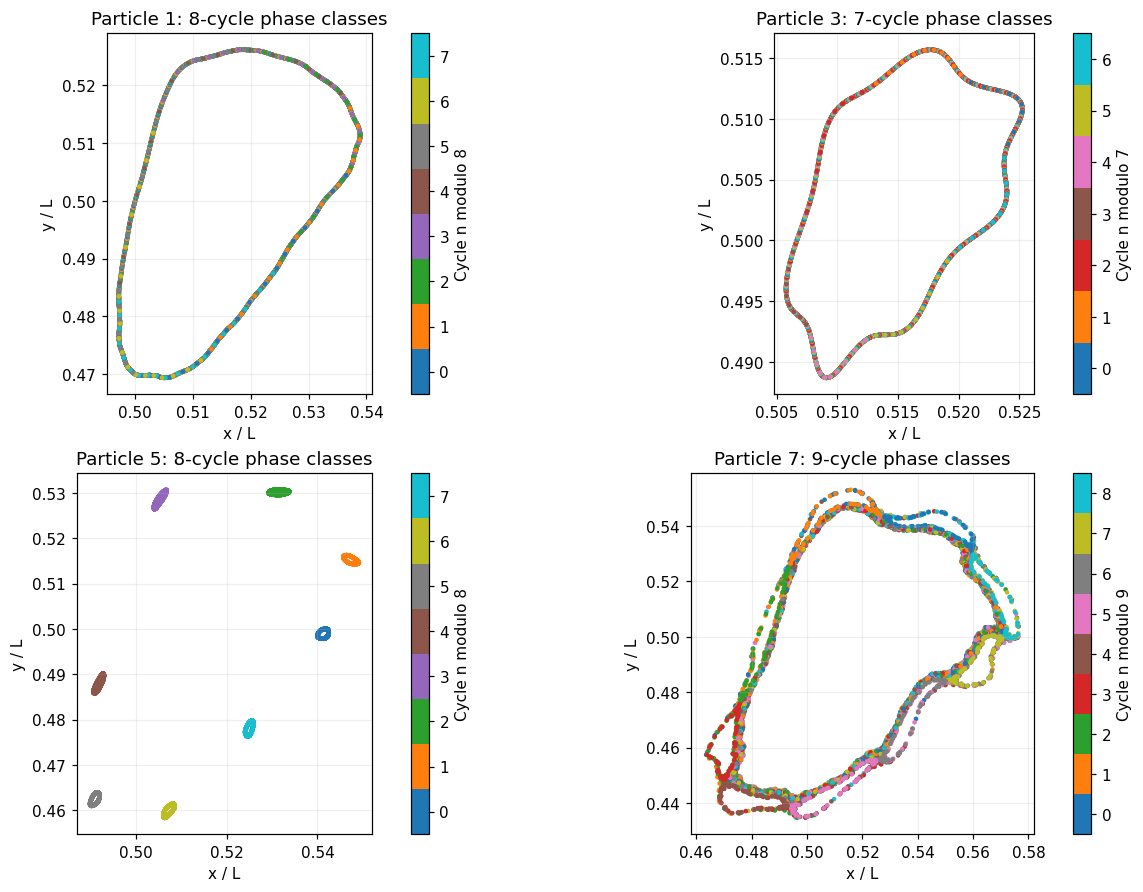

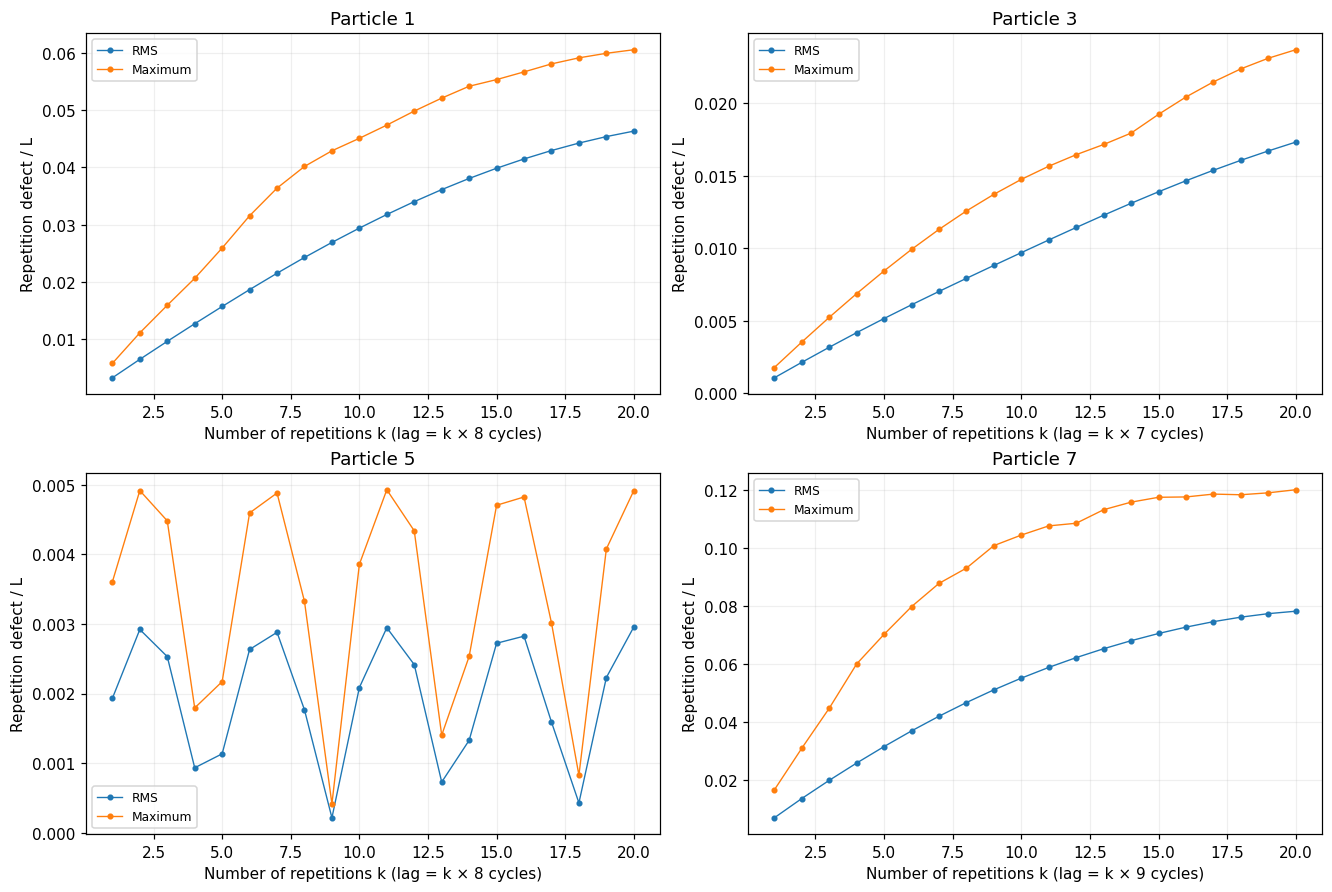

,short_q,rms_over_L,max_over_L,heldout_template_score
particle,,,,
1,8,0.003285,0.005807,-0.002173
3,7,0.001080,0.001788,0.000225
5,8,0.001931,0.003604,0.997970
7,9,0.007026,0.016649,-0.022257


Fraction of all starting cycles with the q-cycle defect below each threshold:


threshold_over_L,0.001,0.005,0.010,0.020
particle,,,,
1,0.000000,0.912277,1.000000,1.0
3,0.499399,1.000000,1.000000,1.0
5,0.094132,1.000000,1.000000,1.0
7,0.023638,0.328526,0.889423,1.0


In [6]:
for diagnostic in ('phase_classes', 'multiples'):
    show_periodicity_figure(plot_short_periodicity(section, analysis, diagnostic=diagnostic),
                            FIGURES if SAVE_PRODUCTS else None, diagnostic)
display(summary[['short_q', 'rms_over_L', 'max_over_L', 'heldout_template_score']])
print('Fraction of all starting cycles with the q-cycle defect below each threshold:')
display(pd.DataFrame(analysis.thresholds).pivot(
    index='particle', columns='threshold_over_L', values='fraction_of_pairs_within',
))

## Interactive selection of visible phase classes

The next cell creates a self-contained offline HTML page with the same four phase-class plots. For each particle, select any combination of classes $n\bmod q$; **All** and **None** controls are available per panel and for the complete page. The HTML embeds every saved once-per-cycle point and can be opened through the generated local link.

In [7]:
from IPython.display import FileLink, IFrame
from visualization.poincare_periodicity import export_phase_class_selector

PHASE_SELECTOR_HTML = FIGURES / 'phase_class_selector.html'
export_phase_class_selector(
    PHASE_SELECTOR_HTML, section, analysis,
    title='Selectable short-period phase classes: particles 1, 3, 5 and 7',
)
display(FileLink(str(PHASE_SELECTOR_HTML), result_html_prefix='Open interactive phase selector: '))
display(IFrame(str(PHASE_SELECTOR_HTML), width='100%', height=1250))

/home/juagil@cartif.local/Investigaciones/GC2D/GC2D_codigo/notebooks/developements/poincare_section/Poincare_BM4Implicit_24_impares_5000_ciclos_40_steps_spot/figuras/aws_bm4implicit_24odd_5000c_40s_20260920/short_periodicity_particles_1_3_5_7/phase_class_selector.html

## Particle 5: persistence of the eight-cycle island pattern

The selected short candidate is also inspected as an explicit q=8 hypothesis. Separate the eight phase classes and zoom into one class. A resolved small loop within a class represents residual modulation about that part of the pattern. The q=8 defect history shows whether the near-repetition continues throughout the record. Exact repetition would collapse each class to a single point.

,short_q,mean_rotation_cycles,rms_over_L,max_over_L,heldout_template_score
particle,,,,,
5,8,8.000025,0.001931,0.003604,0.99797


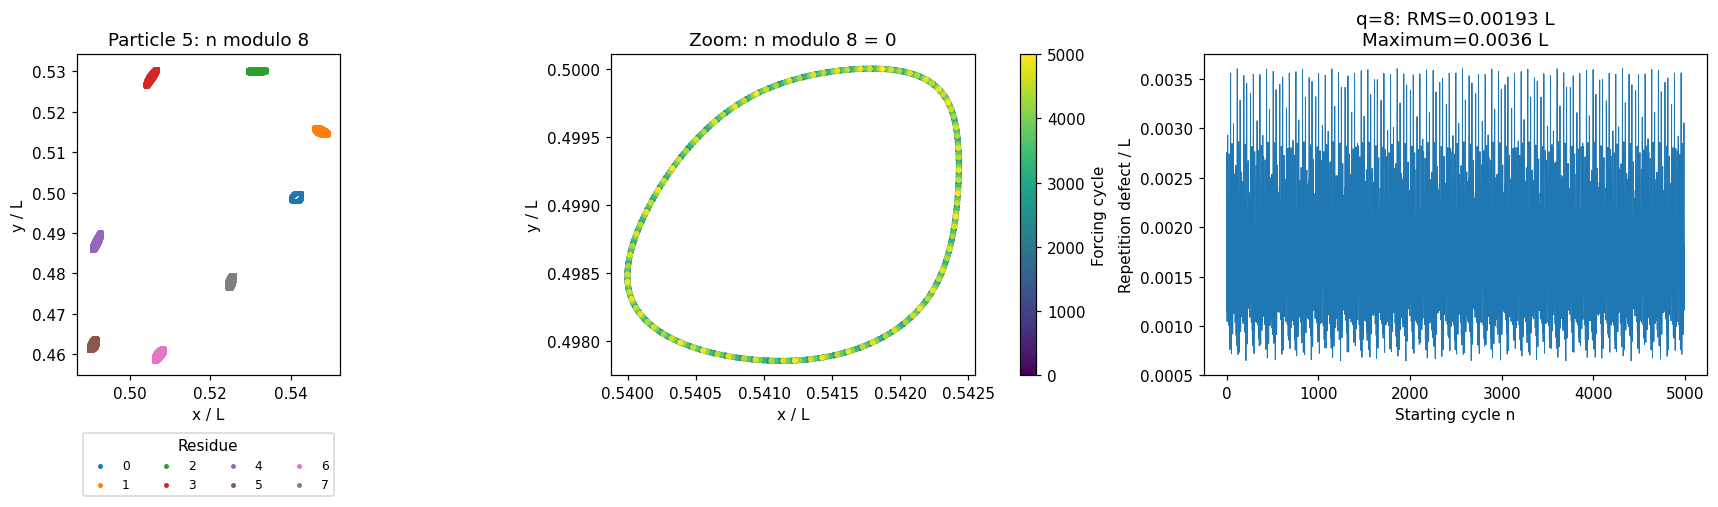

In [8]:
display(summary.loc[[RESONANCE_PARTICLE], ['short_q', 'mean_rotation_cycles',
                                           'rms_over_L', 'max_over_L', 'heldout_template_score']])
show_periodicity_figure(
    plot_residue_section(section, particle_id=RESONANCE_PARTICLE,
                         candidate_q=RESONANCE_LAG, residue=RESONANCE_RESIDUE),
    FIGURES if SAVE_PRODUCTS else None, 'particle_5_eight_cycle_structure',
)

## Computed interpretation

Interpret the short lag, recurring peak spacings, revolution timings, block stability, multiple-shift defects and fixed-pattern score together. A persistent oscillatory rhythm can have a noninteger mean duration and drift relative to a fixed integer-cycle template. An integer-cycle island structure can remain recognizable while its coordinates are modulated. The data do not by themselves certify an exact physical periodic orbit or classify the dynamics as chaotic.

In [9]:
interpretation = short_periodicity_interpretation(analysis)
display(Markdown(interpretation))
if SAVE_PRODUCTS:
    controls = dict(max_lag=MAX_LAG, candidate_max_lag=CANDIDATE_MAX_LAG,
                    peak_height=PEAK_HEIGHT, peak_prominence=PEAK_PROMINENCE,
                    multiple_count=MULTIPLE_COUNT, block_cycles=BLOCK_CYCLES,
                    preview_cycles=PREVIEW_CYCLES, thresholds_over_L=THRESHOLDS_OVER_L,
                    resonance_particle=RESONANCE_PARTICLE, resonance_lag=RESONANCE_LAG,
                    resonance_residue=RESONANCE_RESIDUE,
                    observables='sin/cos of 2*pi*x/L and 2*pi*y/L',
                    sample_rate_per_forcing_cycle=1.0,
                    template_split='First half training; second half evaluation')
    export_short_periodicity(DIAGNOSTICS, section, analysis,
                              controls=controls, interpretation=interpretation)
    print('Short-rhythm tables and source provenance:', DIAGNOSTICS)
    print('Figures:', FIGURES)

- **Particle 1:** recurrent rhythm near **8 cycles**, autocorrelation 0.99095. Mean geometric revolution: **7.842 cycles**, with block means 7.841–7.844. A fixed 8-cycle template trained on the first half has a second-half score of **-0.0022** (1 is perfect; 0 matches a constant baseline). 
- **Particle 3:** recurrent rhythm near **7 cycles**, autocorrelation 0.99519. Mean geometric revolution: **6.901 cycles**, with block means 6.9–6.902. A fixed 7-cycle template trained on the first half has a second-half score of **0.0002** (1 is perfect; 0 matches a constant baseline). 
- **Particle 5:** recurrent rhythm near **8 cycles**, autocorrelation 0.99828. Mean geometric revolution: **8 cycles**, with block means 7.997–8. A fixed 8-cycle template trained on the first half has a second-half score of **0.9980** (1 is perfect; 0 matches a constant baseline). 
- **Particle 7:** recurrent rhythm near **9 cycles**, autocorrelation 0.98942. Mean geometric revolution: **8.869 cycles**, with block means 8.775–9.063. A fixed 9-cycle template trained on the first half has a second-half score of **-0.0223** (1 is perfect; 0 matches a constant baseline). 

Repeated autocorrelation peaks establish a recurring numerical pattern at short lags. A stable noninteger rhythm can gradually slip relative to a fixed integer-cycle template. High template agreement with bounded multiple-lag defects supports a persistent integer-cycle structure, with residual modulation. These diagnostics do not establish an exact physical orbit period; the geometric clock uses interpolated once-per-cycle section positions.

Short-rhythm tables and source provenance: /home/juagil@cartif.local/Investigaciones/GC2D/GC2D_codigo/notebooks/developements/poincare_section/Poincare_BM4Implicit_24_impares_5000_ciclos_40_steps_spot/resultados/aws_bm4implicit_24odd_5000c_40s_20260920/short_periodicity_particles_1_3_5_7
Figures: /home/juagil@cartif.local/Investigaciones/GC2D/GC2D_codigo/notebooks/developements/poincare_section/Poincare_BM4Implicit_24_impares_5000_ciclos_40_steps_spot/figuras/aws_bm4implicit_24odd_5000c_40s_20260920/short_periodicity_particles_1_3_5_7
